In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END
from IPython.display import Image, display

mock_llm called with state: {'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='fcbfaa58-0705-4f5e-914e-781848036e6e')]}
mock_llm2 called with state: {'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='fcbfaa58-0705-4f5e-914e-781848036e6e'), AIMessage(content='hello world from mock_llm!', additional_kwargs={}, response_metadata={}, id='d3058237-2fb4-47eb-a95f-0eb13dc520a5', tool_calls=[], invalid_tool_calls=[])]}
mock_llmEnd called with state: {'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='fcbfaa58-0705-4f5e-914e-781848036e6e'), AIMessage(content='hello world from mock_llm!', additional_kwargs={}, response_metadata={}, id='d3058237-2fb4-47eb-a95f-0eb13dc520a5', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='hello again from mock_llm2!', additional_kwargs={}, response_metadata={}, id='cb8723c3-4f58-487c-9c99-735c853f5143', tool_calls=[], invalid_tool_calls=[]

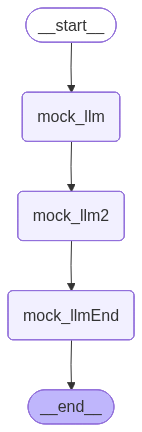

In [2]:

def mock_llm(state: MessagesState):
    print("="*20)
    print("mock_llm called with state:", state)
    return {"messages": [{"role": "ai", "content": "hello world from mock_llm!"}]}

def mock_llm2(state: MessagesState):
    print("="*20)
    print("mock_llm2 called with state:", state)
    return {"messages": [{"role": "ai", "content": "hello again from mock_llm2!"}]}

def mock_llmEnd(state: MessagesState):
    print("="*20)
    print("mock_llmEnd called with state:", state)
    return {"messages": [{"role": "ai", "content": "goodbye from mock_llmEnd!"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_node(mock_llm2)
graph.add_node(mock_llmEnd)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", "mock_llm2")
graph.add_edge("mock_llm2", "mock_llmEnd")
graph.add_edge("mock_llmEnd", END)
graph = graph.compile()

result = graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

for message in result.get("messages"):
    message.pretty_print()

display(Image(graph.get_graph().draw_mermaid_png()))
